# DCT Laboratory — Volume I, Chapter 6
## Enterprise Transformation Operators
**Seed `26106`** · Companion to the chapter and AXIOM Module **AXIOM-06**

The verb's grammar, computed: **iteration** driving the state to the sustainable
core (the invariant fixed point of a contraction), **composition** where order
matters, and **reachability** — which target configurations any sequence of feasible
programs can attain. Mirrored in `DCT_V1_Ch06_Lab.xlsx`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi']=110

import numpy as np
SEED = 26106
# 2-D state: (x4 technology, x5 efficiency); affine operator T(x) = A x + b
A = np.array([[0.55, 0.15],[0.10, 0.60]])
B = np.array([14.0, 24.0])
X0 = np.array([41.0, 68.0])

def T(x): return A @ x + B
def core():                      # sustainable core = fixed point (I-A)^-1 b
    return np.linalg.solve(np.eye(2) - A, B)
def iterate(k=12, x0=X0):
    xs = np.empty((k+1, 2)); xs[0] = x0
    for i in range(k): xs[i+1] = T(xs[i])
    return xs

# Two named programs for composition/reachability
A1 = np.array([[1.10, 0.00],[-0.06, 0.98]]); B1 = np.array([0.0, 4.0])   # digital push
A2 = np.array([[0.97, 0.05],[0.00, 1.04]]);  B2 = np.array([2.0, 0.0])   # cost program
def T1(x): return A1 @ x + B1
def T2(x): return A2 @ x + B2

def reachable(depth=3):
    """All 2^depth endpoints from X0 applying T1/T2 in every order."""
    states = [X0]
    for _ in range(depth):
        states = [f(s) for s in states for f in (T1, T2)]
    return np.array(states)

TARGET = lambda x: (x[0] >= 48.0) and (x[1] >= 71.0)   # 4 of 8 depth-3 sequences reach it

def reference_values():
    c = core(); xs = iterate()
    r1 = float(np.linalg.norm(xs[1]-c)/np.linalg.norm(xs[0]-c))
    gap = float(np.linalg.norm(T2(T1(X0)) - T1(T2(X0))))
    reach = reachable()
    return {
        "core_x4": round(float(c[0]),4), "core_x5": round(float(c[1]),4),
        "iter10_x4": round(float(xs[10,0]),4), "iter10_x5": round(float(xs[10,1]),4),
        "contraction_ratio": round(r1,4),
        "order_gap": round(gap,4),
        "n_reachable_in_target": int(sum(TARGET(s) for s in reach)),
        "spectral_radius_A": round(float(max(abs(np.linalg.eigvals(A)))),4),
    }
if __name__ == "__main__":
    [print(f"{k:24s} {v}") for k,v in reference_values().items()]

core_x4                  55.7576
core_x5                  73.9394
iter10_x4                55.4884
iter10_x5                73.6732
contraction_ratio        0.6488
order_gap                0.6158
n_reachable_in_target    4
spectral_radius_A        0.7


## Panel 1 — Iteration and the sustainable core
$T(\mathbf{x}) = A\mathbf{x} + \mathbf{b}$ with spectral radius 0.7: a contraction.
Iterates converge geometrically to the **invariant fixed point** — the sustainable
core of §6.4. The contraction ratio measured on the first step already predicts the
whole approach.

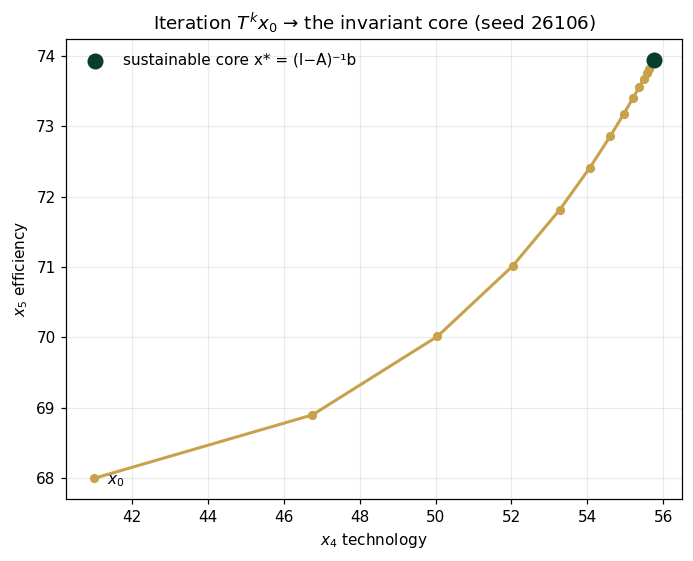

core: [55.7576 73.9394]  iterate k=10: [55.4884 73.6732]
first-step contraction ratio: 0.6488   (spectral radius: 0.7 )


In [2]:
c = core(); xs = iterate(12)
fig, ax = plt.subplots(figsize=(6.4,5.2))
ax.plot(xs[:,0], xs[:,1], "o-", c="#C8A24B", lw=2, ms=5)
ax.scatter([c[0]],[c[1]], c="#0B3D2E", s=90, zorder=5, label="sustainable core x* = (I−A)⁻¹b")
ax.annotate("$x_0$", xs[0], textcoords="offset points", xytext=(8,-4))
ax.set(xlabel="$x_4$ technology", ylabel="$x_5$ efficiency",
       title="Iteration $T^k x_0$ → the invariant core (seed 26106)")
ax.legend(frameon=False); ax.grid(alpha=.25); plt.tight_layout(); plt.show()
print("core:", np.round(c,4), " iterate k=10:", np.round(xs[10],4))
print("first-step contraction ratio:", round(float(np.linalg.norm(xs[1]-c)/np.linalg.norm(xs[0]-c)),4),
      "  (spectral radius:", round(float(max(abs(np.linalg.eigvals(A)))),4),")")

## Panel 2 — Composition: order matters
The digital push $T_1$ then the cost program $T_2$, versus the reverse. Same two
operators, different terminal states — the Transformation Composition Theorem says
composites are valid operators; it does not say they commute.

In [3]:
a = T2(T1(X0)); b = T1(T2(X0))
print("T2∘T1(x0):", np.round(a,4))
print("T1∘T2(x0):", np.round(b,4))
print("order gap ‖·‖:", round(float(np.linalg.norm(a-b)),4))

T2∘T1(x0): [49.156  70.9072]
T1∘T2(x0): [49.687  70.5954]
order gap ‖·‖: 0.6158


## Panel 3 — Reachability under a feasible set
Every depth-3 sequence over $\{T_1, T_2\}$: $2^3 = 8$ endpoints from one $x_0$.
The target region ($x_4 \ge 48$, $x_5 \ge 71$) is reached by exactly **4** sequences
— reachability is a property of the *set* of feasible operators, not of any single
program (§6.6).

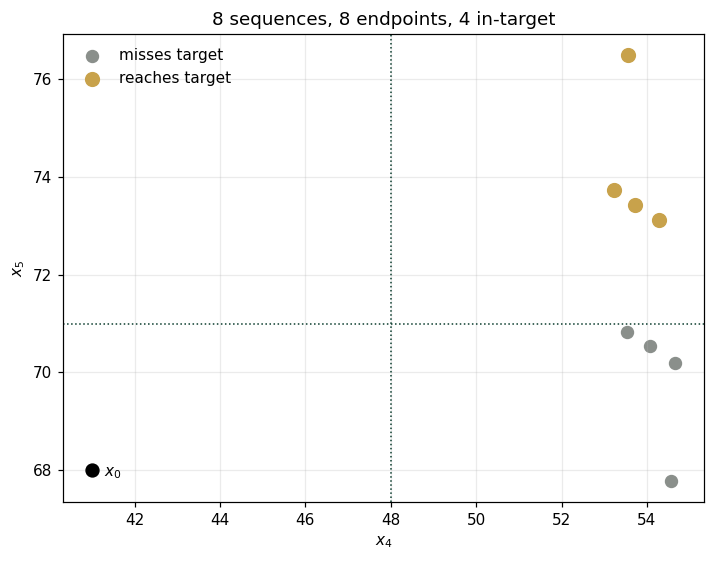

endpoints in target: 4 of 8


In [4]:
r = reachable(3)
fig, ax = plt.subplots(figsize=(6.6,5.2))
inT = np.array([TARGET(s) for s in r])
ax.scatter(r[~inT,0], r[~inT,1], c="#8A8F8B", s=60, label="misses target")
ax.scatter(r[inT,0],  r[inT,1],  c="#C8A24B", s=80, label="reaches target")
ax.scatter([X0[0]],[X0[1]], c="k", s=70, zorder=5)
ax.annotate("$x_0$", X0, textcoords="offset points", xytext=(8,-4))
ax.axvline(48, ls=":", c="#0B3D2E", lw=1); ax.axhline(71, ls=":", c="#0B3D2E", lw=1)
ax.set(xlabel="$x_4$", ylabel="$x_5$", title="8 sequences, 8 endpoints, 4 in-target")
ax.legend(frameon=False); ax.grid(alpha=.25); plt.tight_layout(); plt.show()
print("endpoints in target:", int(inT.sum()), "of", len(r))

## Validation — agrees with `DCT_V1_Ch06_Lab.xlsx`

In [5]:
ref = reference_values()
expected = {"core_x4":55.7576,"core_x5":73.9394,"iter10_x4":55.4884,"iter10_x5":73.6732,
 "contraction_ratio":0.6488,"order_gap":0.6158,"n_reachable_in_target":4,"spectral_radius_A":0.7}
for k,v in expected.items():
    assert abs(ref[k]-v)<5e-4, f"MISMATCH {k}"
    print(f"PASS  {k:24s} {ref[k]}")
print("\nAll checkpoints agree — seed 26106.")

PASS  core_x4                  55.7576
PASS  core_x5                  73.9394
PASS  iter10_x4                55.4884
PASS  iter10_x5                73.6732
PASS  contraction_ratio        0.6488
PASS  order_gap                0.6158
PASS  n_reachable_in_target    4
PASS  spectral_radius_A        0.7

All checkpoints agree — seed 26106.


**Next**: Exercises 6.9–6.12 (Part C); AXIOM-06's operator bench animates iteration and reachability trees. Solutions: IM Ch. 6.